In [4]:
import pandas as pd

orders = pd.read_csv("datas/olist_orders_dataset.csv")
order_items = pd.read_csv("datas/olist_order_items_dataset.csv")
payments = pd.read_csv("datas/olist_order_payments_dataset.csv")
customers = pd.read_csv("datas/olist_customers_dataset.csv")
products = pd.read_csv("datas/olist_products_dataset.csv")
category_translation = pd.read_csv("datas/product_category_name_translation.csv")

print("done!")

done!


In [5]:
for name, df in {"orders": orders, "items": order_items, "payments": payments, 
                  "customers": customers, "products": products}.items():
    print(f"\n--- {name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Nulls:\n{df.isnull().sum()}")


--- orders ---
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
Nulls:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

--- items ---
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
Nulls:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

--- payments ---
Shape: (103886, 5)
Columns: ['order_id', 'payment_sequential', 'payment_type', '

In [6]:
# merge orders + items + products + category translation + customers
df = orders.merge(order_items, on="order_id") \
           .merge(products, on="product_id") \
           .merge(category_translation, on="product_category_name", how="left") \
           .merge(customers, on="customer_id")

print(df.shape)
print(df.columns.tolist())

(112650, 27)
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [7]:
#filling the missing categories
df['product_category_name_english'] = df['product_category_name_english'].fillna('Unknown')


In [8]:

# convert dates
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [9]:
# extract month and year for seasonal analysis later
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

In [10]:
#  create revenue column
df['revenue'] = df['price'] + df['freight_value']

#  keep only delivered orders for revenue analysis
df_delivered = df[df['order_status'] == 'delivered']


In [11]:
print("Total orders:", len(df))
print("Delivered orders:", len(df_delivered))
print("Total revenue:", df_delivered['revenue'].sum())

Total orders: 112650
Delivered orders: 110197
Total revenue: 15419773.75


In [12]:
# 1. revenue by product category
category_revenue = df_delivered.groupby('product_category_name_english')['revenue'].sum()
category_revenue = category_revenue.sort_values(ascending=False).head(10)
print("Top categories:", category_revenue)



Top categories: product_category_name_english
health_beauty            1412089.53
watches_gifts            1264333.12
bed_bath_table           1225209.26
sports_leisure           1118256.91
computers_accessories    1032723.77
furniture_decor           880329.92
housewares                758392.25
cool_stuff                691680.89
auto                      669454.75
garden_tools              567145.68
Name: revenue, dtype: float64


In [13]:
# 2. revenue by state
state_revenue = df_delivered.groupby('customer_state')['revenue'].sum()
state_revenue = state_revenue.sort_values(ascending=False).head(10)
print("Top states:", state_revenue)



Top states: customer_state
SP    5769703.15
RJ    2055401.57
MG    1818891.67
RS     861472.79
PR     781708.80
SC     595127.78
BA     591137.81
DF     346123.35
GO     334212.35
ES     317657.93
Name: revenue, dtype: float64


In [14]:
# 3. revenue by month
month_revenue = df_delivered.groupby('month')['revenue'].sum()
print("Revenue by month:", month_revenue)

Revenue by month: month
1     1205369.83
2     1237407.73
3     1534929.19
4     1523691.33
5     1695625.92
6     1502028.66
7     1594106.36
8     1631324.00
9      701220.95
10     797607.67
11    1153364.20
12     843097.91
Name: revenue, dtype: float64


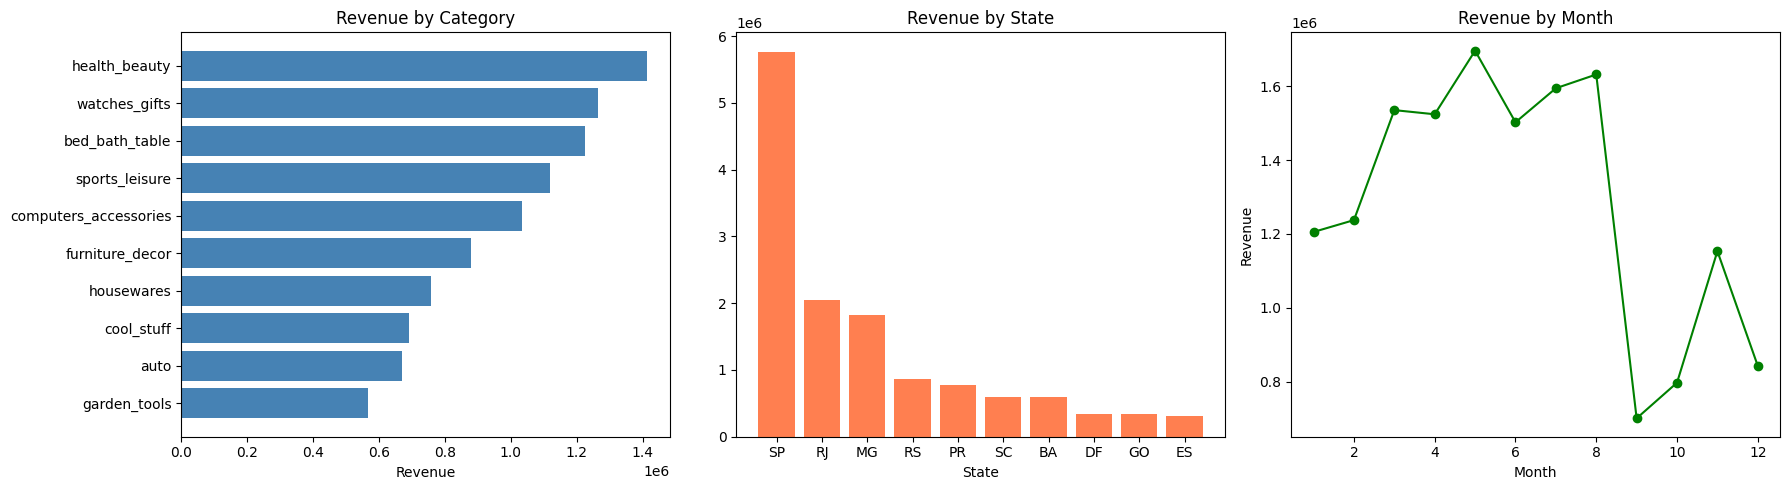

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# top categories
axes[0].barh(category_revenue.index, category_revenue.values, color='steelblue')
axes[0].set_title('Revenue by Category')
axes[0].set_xlabel('Revenue')
axes[0].invert_yaxis()

# top states
axes[1].bar(state_revenue.index, state_revenue.values, color='coral')
axes[1].set_title('Revenue by State')
axes[1].set_xlabel('State')

# monthly trend
axes[2].plot(month_revenue.index, month_revenue.values, marker='o', color='green')
axes[2].set_title('Revenue by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

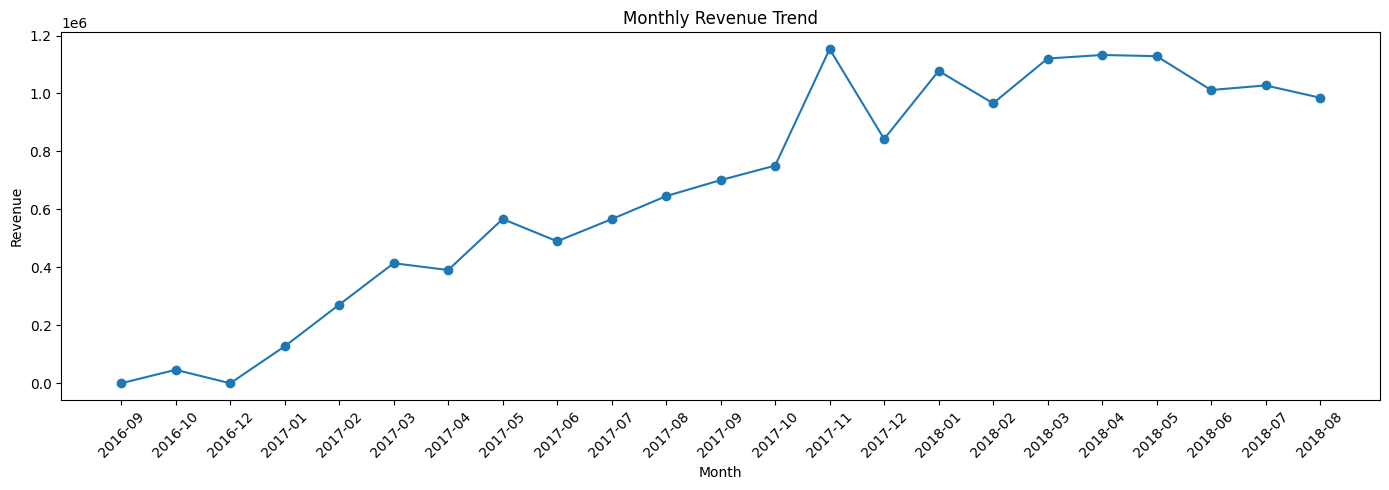

In [16]:
# group by month_year for proper time series
monthly = df_delivered.groupby('month_year')['revenue'].sum().reset_index()
monthly['month_year'] = monthly['month_year'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly['month_year'], monthly['revenue'], marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
#Purchase Prediction
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

customer_orders = df_delivered.groupby('customer_unique_id')['order_id'].nunique()
df_delivered['repeat_buyer'] = df_delivered['customer_unique_id'].map(
    lambda x: 1 if customer_orders[x] > 1 else 0
)

features = df_delivered[['price', 'freight_value', 'month']].copy()
target = df_delivered['repeat_buyer']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     20626
           1       0.00      0.00      0.00      1414

    accuracy                           0.94     22040
   macro avg       0.47      0.50      0.48     22040
weighted avg       0.88      0.94      0.90     22040



/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [18]:
# Customer Segmentation
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

customer_features = df_delivered.groupby('customer_unique_id').agg(
    total_spent=('revenue', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('revenue', 'mean')
).reset_index()

scaler = StandardScaler()
scaled = scaler.fit_transform(customer_features[['total_spent', 'total_orders', 'avg_order_value']])

kmeans = KMeans(n_clusters=3, random_state=42)
customer_features['cluster'] = kmeans.fit_predict(scaled)

print(customer_features.groupby('cluster')[['total_spent', 'total_orders', 'avg_order_value']].mean())

         total_spent  total_orders  avg_order_value
cluster                                            
0        1054.157155      1.008538       961.269814
1         131.430324      1.000000       119.682356
2         292.798271      2.114914       117.552081


- **Focus on São Paulo (SP)** – Around 37% of revenue comes from SP. they should invest in faster delivery and run promotions specifically for customers there.
- **Promote Health & Beauty** – This category brings in the most revenue. they can create bundles and give loyalty discounts to encourage more sales.
- **Plan November campaigns** – Revenue jumps in November (Black Friday). Make sure to stock up early and run strong marketing campaigns that month.
